In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

FONTSIZE = 20
FIGSIZE = 5

MEDIUM_SIZE = FONTSIZE
SMALL_SIZE = 0.75 * MEDIUM_SIZE
BIGGER_SIZE = 1.5 * MEDIUM_SIZE

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title



In [2]:
def calculate_binomial_coefficients(n):
    coefficients = np.zeros((n+1, n+1))
    for i in range(n+1):
        for j in range(i+1):
            if j == 0 or j == i:
                coefficients[i][j] = 1
            else:
                coefficients[i][j] = coefficients[i-1][j-1] + coefficients[i-1][j]
    return coefficients

def calculate_failure_probability_bahadur(x, n, K, rho, mode='correlated_suppliers'):
    z = 0
    q = x**n
    if mode == 'correlated_suppliers':
        C = calculate_binomial_coefficients(n)
        z = q
        for j in range(2, n + 1):
            z += C[n, j] * rho * (1 - x)**(j / 2) * x**(n - j / 2)
    elif mode == 'correlated_products':
        C = calculate_binomial_coefficients(K)
        for b in range(0, K):
            temp = 1
            for j in range(2, K + 1):
                for r in range(0, min(j, b + 1) + 1):
                    temp += C[j, r] * C[K - j, j - r] * rho * (1 - q)**(j / 2) * q**(j / 2 - r)

            z += temp * C[K - 1, b] * q**(b + 1) * (1 - q)**(K - b - 1)

    elif mode == 'correlated_all':
        N = n * K

        C = calculate_binomial_coefficients(N)

        for b in range(0, N - n + 1):
            temp = 1
            for j in range(2, N + 1):
                for r in range(0, min(j, b + n) + 1):
                    temp += C[j, r] * C[N - j, j - r] * rho * (1 - x)**(j / 2) * x**(j / 2 - r)

            z += temp * C[N - n, b] * x**(b + n) * (1 - x)**(N - n - b)

    return z  



/var/folders/8n/s26krq6n1vb_73jtxvb8k8th0000gn/T/ipykernel_19626/4200068955.py:25: RuntimeWarning: divide by zero encountered in scalar power
  temp += C[j, r] * C[K - j, j - r] * rho * (1 - q)**(j / 2) * q**(j / 2 - r)
/var/folders/8n/s26krq6n1vb_73jtxvb8k8th0000gn/T/ipykernel_19626/4200068955.py:25: RuntimeWarning: invalid value encountered in scalar multiply
  temp += C[j, r] * C[K - j, j - r] * rho * (1 - q)**(j / 2) * q**(j / 2 - r)
/var/folders/8n/s26krq6n1vb_73jtxvb8k8th0000gn/T/ipykernel_19626/4200068955.py:38: RuntimeWarning: divide by zero encountered in scalar power
  temp += C[j, r] * C[N - j, j - r] * rho * (1 - x)**(j / 2) * x**(j / 2 - r)
/var/folders/8n/s26krq6n1vb_73jtxvb8k8th0000gn/T/ipykernel_19626/4200068955.py:38: RuntimeWarning: invalid value encountered in scalar multiply
  temp += C[j, r] * C[N - j, j - r] * rho * (1 - x)**(j / 2) * x**(j / 2 - r)
/var/folders/8n/s26krq6n1vb_73jtxvb8k8th0000gn/T/ipykernel_19626/4200068955.py:27: RuntimeWarning: invalid value enc

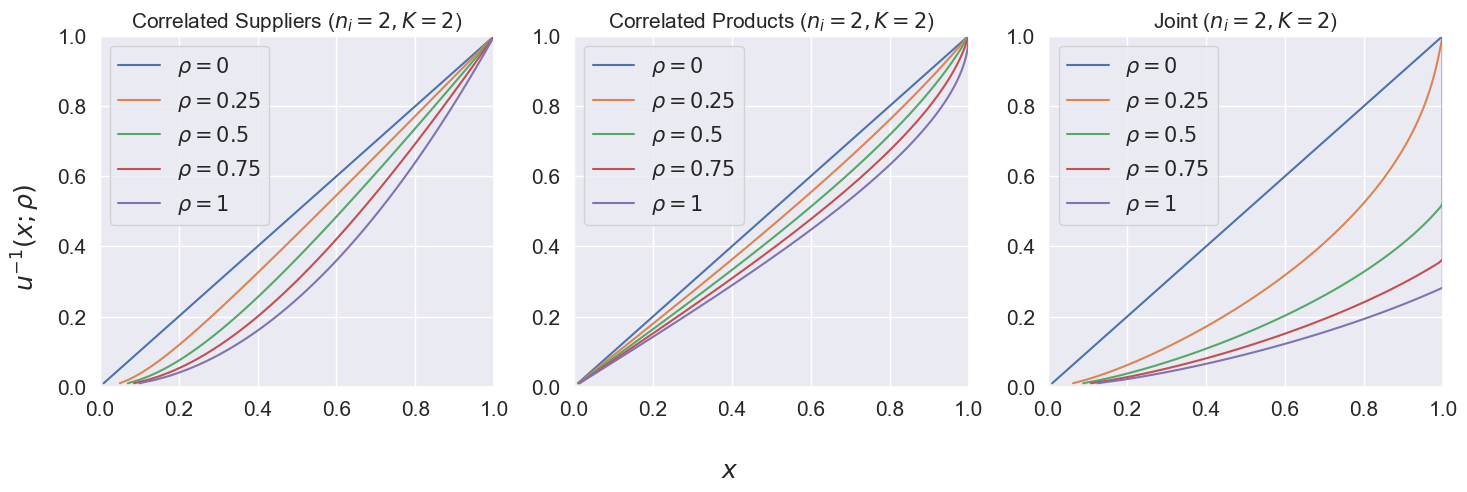

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))


n = 2
K = 2

ax[0].set_title(f'Correlated Suppliers ($n_i = {n}, K = {K}$)')
ax[1].set_title(f'Correlated Products ($n_i = {n}, K = {K}$)')
ax[2].set_title(f'Joint ($n_i = {n}, K = {K}$)')

fig.supxlabel('$x$')
fig.supylabel('$u^{-1}(x; \\rho)$')

x_space = np.linspace(0, 1, 100)

rhos = [0, 0.25, 0.5, 0.75, 1]

for rho in rhos:

    failure_probabilities_suppliers = np.array([min(1, calculate_failure_probability_bahadur(x, n, K, rho, mode='correlated_suppliers')**(1/n)) for x in x_space])
    failure_probabilities_products = np.array([min(1, calculate_failure_probability_bahadur(x, n, K, rho, mode='correlated_products')**(1/n)) for x in x_space])
    failure_probabilities_all = np.array([min(1, calculate_failure_probability_bahadur(x, n, K, rho, mode='correlated_all')**(1/n)) for x in x_space])

    ax[0].plot(failure_probabilities_suppliers[1:], x_space[1:], label=f'$\\rho={rho}$')
    ax[1].plot(failure_probabilities_products[1:], x_space[1:], label=f'$\\rho={rho}$')
    ax[2].plot(failure_probabilities_all[1:], x_space[1:], label=f'$\\rho={rho}$')
   

ax[0].set_xlim(0, 1)
ax[0].set_ylim(0, 1)
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, 1)
ax[2].set_xlim(0, 1)
ax[2].set_ylim(0, 1)

ax[0].legend()
ax[1].legend()
ax[2].legend()

fig.tight_layout()

fig.savefig('bahadur_correlated.pdf', bbox_inches='tight')
